5-Fold CV Evaluation Progress: 100%|█████████████████████████████████████████████████████| 5/5 [00:00<00:00, 12.18it/s]



Cross-Validation Results for Each Fold:

Fold 1:
  MSE : 2.1475
  RMSE: 1.4654
  MAE : 1.0963
  MRE : 13.24%
  R2  : 0.7968

Fold 2:
  MSE : 0.6945
  RMSE: 0.8333
  MAE : 0.6594
  MRE : 6.35%
  R2  : 0.8527

Fold 3:
  MSE : 1.3807
  RMSE: 1.1750
  MAE : 0.9887
  MRE : 7.74%
  R2  : 0.6039

Fold 4:
  MSE : 0.6760
  RMSE: 0.8222
  MAE : 0.6423
  MRE : 10.25%
  R2  : 0.9227

Fold 5:
  MSE : 3.1311
  RMSE: 1.7695
  MAE : 1.4005
  MRE : 14.68%
  R2  : 0.6975


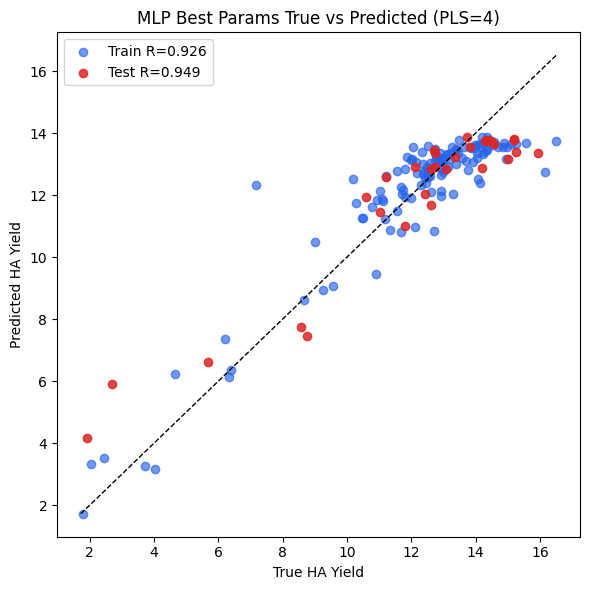

MLP Best Parameters:
{'mlp__activation': 'tanh', 'mlp__alpha': 2.5343221083724825e-05, 'mlp__batch_size': 32, 'mlp__beta_1': 0.85, 'mlp__beta_2': 0.999, 'mlp__hidden_layer_sizes': (8,), 'mlp__learning_rate': 'adaptive', 'mlp__learning_rate_init': 0.006627897035983008}

PLS Components: 4
PLS Cumulative Variance Ratio: 97.2369%

===== Cross-Validation (5-fold Average) =====
MSE : 1.6059 ± 0.9344
RMSE: 1.2131 ± 0.3665
MAE : 0.9574 ± 0.2845
MRE : 10.45% ± 3.16%
R2  : 0.7747 ± 0.1128

===== Training Set Metrics =====
MSE: 1.1156
RMSE: 1.0562
MAE: 0.7704
MRE: 7.53%
R2: 0.8550
Pearson R: 0.9260

===== Test Set Metrics =====
MSE: 1.5827
RMSE: 1.2581
MAE: 1.0150
MRE: 14.66%
R2: 0.8644
Pearson R: 0.9487


In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from tqdm import tqdm

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")

base_dir = Path.cwd()
spectra_path = base_dir / "pattern.xlsx"
label_path = base_dir / "label.xlsx"

output_path = spectra_path.with_name("MLP.xlsx")
output_dir = spectra_path.parent / "mlp_pls4_best_params_visual"
output_dir.mkdir(exist_ok=True)

cv_predictions_dir = output_dir / "cv_fold_predictions"
cv_predictions_dir.mkdir(exist_ok=True)

spectra_df = pd.read_excel(spectra_path, header=None)
label_df = pd.read_excel(label_path, header=None)

id_col = "SampleID"
target_col = "HA_Yield"

feature_cols = [f"Feature_{i}" for i in range(1, spectra_df.shape[1])]
spectra_df.columns = [id_col] + feature_cols

label_df = label_df.iloc[:, :2].copy()
label_df.columns = [id_col, target_col]

def normalize_id(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        return str(int(x)) if x.is_integer() else str(x).rstrip("0").rstrip(".")
    return str(x).strip()

def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return np.corrcoef(y_true, y_pred)[0, 1]

spectra_df[id_col] = spectra_df[id_col].map(normalize_id)
label_df[id_col] = label_df[id_col].map(normalize_id)
label_df[target_col] = pd.to_numeric(label_df[target_col], errors="coerce")

label_check = label_df.groupby(id_col)[target_col].nunique(dropna=False)
conflict_ids = label_check[label_check > 1].index.tolist()
if conflict_ids:
    raise ValueError(f"The following SampleIDs correspond to multiple different HA Yield values, please check label.xlsx: {conflict_ids}")

label_unique = label_df.drop_duplicates(subset=[id_col], keep="first")
df = spectra_df.merge(label_unique, on=id_col, how="left")
if df[target_col].isna().any():
    missing_ids = df.loc[df[target_col].isna(), id_col].unique()
    raise ValueError(f"The following SampleIDs cannot find matching HA Yield in label.xlsx: {missing_ids}")

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.mean()).fillna(0)
y = df[target_col].astype(float)

X_standard = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0).replace(0, 1)

n_components = 4
max_components = min(X_standard.shape[0] - 1, X_standard.shape[1])
if n_components > max_components:
    raise ValueError(f"A maximum of {max_components} PLS components can be extracted from current dataset, cannot set to {n_components}.")

pls = PLSRegression(n_components=n_components, scale=False)
pls.fit(X_standard.values, y.values.reshape(-1, 1))

X_scores = pls.x_scores_
X_reconstructed = X_scores @ pls.x_loadings_.T
ss_total = np.sum(X_standard.values ** 2)
ss_residual = np.sum((X_standard.values - X_reconstructed) ** 2)
cumulative_variance_ratio = 1 - ss_residual / ss_total

pls_cols = [f"PLS_Component_{i + 1}" for i in range(n_components)]
df_pls = pd.DataFrame(X_scores, columns=pls_cols)
df_pls.insert(0, id_col, df[id_col].values)
df_pls[target_col] = y.values

X_model = df_pls[pls_cols].astype(float)
y_model = df_pls[target_col].astype(float)
groups = df_pls[id_col].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_model, y_model, groups=groups))

X_train = X_model.iloc[train_idx]
X_test = X_model.iloc[test_idx]
y_train = y_model.iloc[train_idx]
y_test = y_model.iloc[test_idx]
groups_train = groups.iloc[train_idx]

best_params = {
    "mlp__activation": "tanh",
    "mlp__alpha": 2.5343221083724825e-05,
    "mlp__batch_size": 32,
    "mlp__beta_1": 0.85,
    "mlp__beta_2": 0.999,
    "mlp__hidden_layer_sizes": (8,),
    "mlp__learning_rate": "adaptive",
    "mlp__learning_rate_init": 0.006627897035983008
}

def create_model():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            solver="adam",
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=30,
            max_iter=3000,
            random_state=42
        ))
    ])
    model.set_params(**best_params)
    return model

n_splits = min(5, groups_train.nunique())
if n_splits < 2:
    raise ValueError("The number of unique SampleID groups in training set is insufficient to perform GroupKFold cross validation.")

cv = GroupKFold(n_splits=n_splits)
cv_folds = list(cv.split(X_train, y_train, groups=groups_train))

cv_mse_scores = []
cv_rmse_scores = []
cv_mae_scores = []
cv_mre_scores = []
cv_r2_scores = []
cv_predictions = []

for fold_idx, (train_idx_cv, val_idx_cv) in enumerate(tqdm(cv_folds, desc="5-Fold CV Evaluation Progress")):
    X_tr = X_train.iloc[train_idx_cv]
    y_tr = y_train.iloc[train_idx_cv]
    X_val = X_train.iloc[val_idx_cv]
    y_val = y_train.iloc[val_idx_cv]
    
    fold_model = create_model()
    fold_model.fit(X_tr, y_tr)
    y_val_pred = fold_model.predict(X_val)
    
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)
    mre_val = np.mean(np.abs(y_val - y_val_pred) / y_val) * 100
    r2_val = r2_score(y_val, y_val_pred)
    
    cv_mse_scores.append(mse_val)
    cv_rmse_scores.append(rmse_val)
    cv_mae_scores.append(mae_val)
    cv_mre_scores.append(mre_val)
    cv_r2_scores.append(r2_val)
    
    fold_pred_df = pd.DataFrame({
        id_col: df_pls.iloc[train_idx].iloc[val_idx_cv][id_col].values,
        "Fold": f"Fold_{fold_idx + 1}",
        "True_HA_Yield": y_val.values,
        "Predicted_HA_Yield": y_val_pred,
        "Residual": y_val.values - y_val_pred,
        "Absolute_Error": np.abs(y_val.values - y_val_pred),
        "Relative_Error_%": np.abs(y_val.values - y_val_pred) / y_val.values * 100
    })
    cv_predictions.append(fold_pred_df)
    
    fold_output_path = cv_predictions_dir / f"fold_{fold_idx + 1}_predictions.xlsx"
    with pd.ExcelWriter(fold_output_path, engine="openpyxl") as writer:
        fold_pred_df.to_excel(writer, sheet_name="predictions", index=False)
        fold_metrics_df = pd.DataFrame({
            "Metric": ["MSE", "RMSE", "MAE", "MRE_%", "R2"],
            "Value": [mse_val, rmse_val, mae_val, mre_val, r2_val]
        })
        fold_metrics_df.to_excel(writer, sheet_name="metrics", index=False)
        fold_info_df = pd.DataFrame({
            "Info": ["Training samples", "Validation samples", "Fold number"],
            "Value": [len(X_tr), len(X_val), fold_idx + 1]
        })
        fold_info_df.to_excel(writer, sheet_name="info", index=False)

cv_mse = np.mean(cv_mse_scores)
cv_rmse = np.mean(cv_rmse_scores)
cv_mae = np.mean(cv_mae_scores)
cv_mre = np.mean(cv_mre_scores)
cv_r2 = np.mean(cv_r2_scores)

cv_mse_std = np.std(cv_mse_scores)
cv_rmse_std = np.std(cv_rmse_scores)
cv_mae_std = np.std(cv_mae_scores)
cv_mre_std = np.std(cv_mre_scores)
cv_r2_std = np.std(cv_r2_scores)

print("\n" + "="*60)
print("Cross-Validation Results for Each Fold:")
print("="*60)
for i in range(n_splits):
    print(f"\nFold {i+1}:")
    print(f"  MSE : {cv_mse_scores[i]:.4f}")
    print(f"  RMSE: {cv_rmse_scores[i]:.4f}")
    print(f"  MAE : {cv_mae_scores[i]:.4f}")
    print(f"  MRE : {cv_mre_scores[i]:.2f}%")
    print(f"  R2  : {cv_r2_scores[i]:.4f}")

model = create_model()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_mre = np.mean(np.abs(y_train - y_train_pred) / y_train) * 100
test_mre = np.mean(np.abs(y_test - y_test_pred) / y_test) * 100
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_r = pearson_r(y_train, y_train_pred)
test_r = pearson_r(y_test, y_test_pred)
r_gap = train_r - test_r
train_r_greater = train_r > test_r
r_gap_le_015 = 0 <= r_gap <= 0.15

train_result_df = pd.DataFrame({
    id_col: df_pls.iloc[train_idx][id_col].values,
    "Dataset": "Training",
    "True_HA_Yield": y_train.values,
    "Predicted_HA_Yield": y_train_pred,
    "Residual": y_train.values - y_train_pred
})
test_result_df = pd.DataFrame({
    id_col: df_pls.iloc[test_idx][id_col].values,
    "Dataset": "Test",
    "True_HA_Yield": y_test.values,
    "Predicted_HA_Yield": y_test_pred,
    "Residual": y_test.values - y_test_pred
})
all_result_df = pd.concat([train_result_df, test_result_df], axis=0).reset_index(drop=True)

def id_sort_key(x):
    try:
        return float(str(x).strip())
    except ValueError:
        return np.inf

all_result_df["Sort_Key_ID"] = all_result_df[id_col].map(id_sort_key)
all_result_df["Group_Index"] = all_result_df.groupby(id_col).cumcount() + 1
all_result_sorted_df = all_result_df.sort_values(
    by=["Sort_Key_ID", "Group_Index"],
    ascending=[True, True]
).drop(columns=["Sort_Key_ID"])

metrics_df = pd.DataFrame({
    "Metric": [
        "PLS_Components",
        "PLS_Cumulative_Variance_Ratio",
        "CV_MSE_Average",
        "CV_RMSE_Average",
        "CV_MAE_Average",
        "CV_MRE(%)_Average",
        "CV_R2_Average",
        "CV_MSE_Std",
        "CV_RMSE_Std",
        "CV_MAE_Std",
        "CV_MRE(%)_Std",
        "CV_R2_Std",
        "Train_R",
        "Test_R",
        "Train_R_Minus_Test_R",
        "Train_R_Greater_Than_Test_R",
        "R_Gap_Less_Equal_0.15",
        "Train_R2",
        "Test_R2",
        "Train_MSE",
        "Test_MSE",
        "Train_RMSE",
        "Test_RMSE",
        "Train_MAE",
        "Test_MAE",
        "Train_MRE(%)",
        "Test_MRE(%)"
    ],
    "Value": [
        n_components,
        cumulative_variance_ratio,
        cv_mse,
        cv_rmse,
        cv_mae,
        cv_mre,
        cv_r2,
        cv_mse_std,
        cv_rmse_std,
        cv_mae_std,
        cv_mre_std,
        cv_r2_std,
        train_r,
        test_r,
        r_gap,
        train_r_greater,
        r_gap_le_015,
        train_r2,
        test_r2,
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_mre,
        test_mre
    ]
})

best_params_df = pd.DataFrame(
    list(best_params.items()),
    columns=["Parameter", "Fixed_Value"]
)

plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred, alpha=0.65, label=f"Train R={train_r:.3f}", color="#2563EB")
plt.scatter(y_test, y_test_pred, alpha=0.85, label=f"Test R={test_r:.3f}", color="#DC2626")
min_v = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_v = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1)
plt.xlabel("True HA Yield")
plt.ylabel("Predicted HA Yield")
plt.title("MLP Best Params True vs Predicted (PLS=4)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "true_vs_predicted_train_test.png", dpi=300)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_pls.to_excel(writer, sheet_name="pls_scores_4", index=False)
    train_result_df.to_excel(writer, sheet_name="train_predictions", index=False)
    test_result_df.to_excel(writer, sheet_name="test_predictions", index=False)
    all_result_sorted_df.to_excel(writer, sheet_name="all_predictions_by_id", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)
    best_params_df.to_excel(writer, sheet_name="best_params", index=False)
    
    for fold_pred_df in cv_predictions:
        fold_name = fold_pred_df["Fold"].iloc[0]
        fold_pred_df.to_excel(writer, sheet_name=f"{fold_name}_predictions", index=False)
    
    cv_summary_df = pd.DataFrame({
        "Fold": [f"Fold_{i+1}" for i in range(n_splits)],
        "MSE": cv_mse_scores,
        "RMSE": cv_rmse_scores,
        "MAE": cv_mae_scores,
        "MRE_%": cv_mre_scores,
        "R2": cv_r2_scores
    })
    cv_summary_df.to_excel(writer, sheet_name="cv_fold_summary", index=False)

cv_predictions_summary_path = output_dir / "all_cv_fold_predictions.xlsx"
with pd.ExcelWriter(cv_predictions_summary_path, engine="openpyxl") as writer:
    for fold_pred_df in cv_predictions:
        fold_name = fold_pred_df["Fold"].iloc[0]
        fold_pred_df.to_excel(writer, sheet_name=fold_name, index=False)
    cv_summary_df = pd.DataFrame({
        "Fold": [f"Fold_{i+1}" for i in range(n_splits)],
        "MSE": cv_mse_scores,
        "RMSE": cv_rmse_scores,
        "MAE": cv_mae_scores,
        "MRE_%": cv_mre_scores,
        "R2": cv_r2_scores
    })
    cv_summary_df.to_excel(writer, sheet_name="summary", index=False)

print("="*60)
print("MLP Best Parameters:")
print(best_params)
print(f"\nPLS Components: {n_components}")
print(f"PLS Cumulative Variance Ratio: {cumulative_variance_ratio:.4%}")
print("\n===== Cross-Validation (5-fold Average) =====")
print(f"MSE : {cv_mse:.4f} ± {cv_mse_std:.4f}")
print(f"RMSE: {cv_rmse:.4f} ± {cv_rmse_std:.4f}")
print(f"MAE : {cv_mae:.4f} ± {cv_mae_std:.4f}")
print(f"MRE : {cv_mre:.2f}% ± {cv_mre_std:.2f}%")
print(f"R2  : {cv_r2:.4f} ± {cv_r2_std:.4f}")
print(f"\n===== Training Set Metrics =====")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"MRE: {train_mre:.2f}%")
print(f"R2: {train_r2:.4f}")
print(f"Pearson R: {train_r:.4f}")
print(f"\n===== Test Set Metrics =====")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"MRE: {test_mre:.2f}%")
print(f"R2: {test_r2:.4f}")
print(f"Pearson R: {test_r:.4f}")